In [1]:
import os
import pyproj
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
import csv
from rasterio.windows import from_bounds
from rasterio.mask import mask
from datetime import datetime 

In [2]:
def check_path(x):
    if os.path.exists(x):
        print("The file exists")
    else:
        print("The file does not exist")

#### Read in Raster File

In [3]:
# Define the paths to the raster and vector files
# global_forest_cover = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\raster\Hansen_GFC-2023-v1.11_lossyear_clipped.tif"
# global_forest_cover = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\raster\Hansen_GFC-2024-v1.12_lossyear_clipped.tif"
global_forest_cover = r"C:\Users\Carol\Dropbox\GIS\Projects\RFO_mining\2_intermediate_data\raster\Hansen_GFC2024_lossyear_RFO_clip.tif"
check_path(global_forest_cover)

The file exists


In [4]:
# vector_path = r"C:\Users\Carol\Dropbox\GIS\Projects\IOB_AlbertineRift\2_intermediate_data\AlbertineRift_data.gpkg" #rfo_mining_aoi"
vector_path = r"C:\Users\Carol\Dropbox\GIS\Projects\RFO_mining\2_intermediate_data\vector\RFO_mining.gpkg" #rfo_mining_aoi"
layer_name = "rfo_mining_aoi"

check_path(vector_path)

# vector_path = r"path/to/vector_file.shp"  # Replace with the actual path to your vector file
# layer_name = "AlbertineRift_aoi_utm35s"

The file exists


In [5]:
# Read the vector features
vector_features = gpd.read_file(vector_path, layer=layer_name)
# vector_features = vector_features.to_crs(epsg=4326)

In [6]:
print(vector_features.head())

           source      area_ha   area_km2             aoi_name  \
0  digitized CAMI  8735.924902  87.359249  southwestern sector   
1  digitized CAMI  5956.718734  59.567187     western boundary   

                                            geometry  
0  MULTIPOLYGON (((609800.801 146742.636, 609801....  
1  MULTIPOLYGON (((609696.329 182435.986, 614541....  


Select which of the AOI features to use for the deforestation alert trend analysis

In [7]:
# Select 2 of the 3 AOI features by aoi_name
selected_aoi_names = ['southwestern sector', 'western boundary']  # Replace with the actual AOI names you want to select
vector_features = vector_features[vector_features['aoi_name'].isin(selected_aoi_names)]

In [8]:
vector_features.crs

<Projected CRS: EPSG:32635>
Name: WGS 84 / UTM zone 35N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 24°E and 30°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Bulgaria. Central African Republic. Democratic Republic of the Congo (Zaire). Egypt. Estonia. Finland. Greece. Latvia. Lesotho. Libya. Lithuania. Moldova. Norway. Poland. Romania. Russian Federation. Sudan. Svalbard. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (24.0, 0.0, 30.0, 84.0)
Coordinate Operation:
- name: UTM zone 35N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
global_forest_cover
# Read the raster data

'C:\\Users\\Carol\\Dropbox\\GIS\\Projects\\RFO_mining\\2_intermediate_data\\raster\\Hansen_GFC2024_lossyear_RFO_clip.tif'

In [10]:
# Set the PROJ_LIB environment variable
proj_lib_path = r'C:\ProgramData\miniconda3\envs\rasterio\Lib\site-packages\pyproj'
os.environ['PROJ_LIB'] = proj_lib_path

# Set the PROJ data directory using pyproj
pyproj.datadir.set_data_dir(proj_lib_path)

# Verify the PROJ data directory
print(f"PROJ data directory: {pyproj.datadir.get_data_dir()}")

PROJ data directory: C:\ProgramData\miniconda3\envs\rasterio\Library\share\proj


In [11]:
# Open the raster file and read in the data
with rasterio.open(global_forest_cover) as src:
    
    # Get the bounds of the bounding box
    bbox = src.bounds

    # Convert bounds to a rasterio window
    window = from_bounds(bbox[0], bbox[1], bbox[2], bbox[3], src.transform)
    
    # Read raster within this window
    data = src.read(1, window=window)

print(f"Raster data shape:", bbox)

Raster data shape: BoundingBox(left=583446.0, bottom=110539.0, right=750196.0, top=276541.0)


#### Check the CRS for the raster file

In [12]:
src.crs

if src.crs != vector_features.crs:
    print(f"{src.crs} is not equal to {vector_features.crs}")
else:
    print(f"{src.crs} is equal to {vector_features.crs}")

EPSG:32635 is equal to epsg:32635


In [13]:
geoms = [geom for geom in vector_features['geometry']] #.tolist()
geoms

[<MULTIPOLYGON (((6.1e+05 1.47e+05, 6.1e+05 1.47e+05, 6.1e+05 1.46e+05, 6.1e+...>,
 <MULTIPOLYGON (((6.1e+05 1.82e+05, 6.15e+05 1.82e+05, 6.15e+05 1.8e+05, 6.18...>]

In [14]:
# Open the raster file
with rasterio.open(global_forest_cover) as src:
    # Initialize a variable to hold the total deforestation area
    total_deforestation_area = 0
    
    for geom in geoms:
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geoms, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]

        # Create a mask for the deforested pixels (assuming deforestation years are between 1 and 23)
        deforestation_mask = (data >= 1) & (data <= 24)
        
        # Calculate the deforestation area (10m x 10m pixels)
        # deforestation_area = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area
        # deforestation_area = np.sum((data >= 1) & (data <= 23)) * 768.2975  # (27.71818m x 27.71818m = 100m²
        deforestation_area_sqm = np.sum(deforestation_mask) * src.res[0] * src.res[1]

        # Add the deforestation area to the total
        total_deforestation_area += deforestation_area_sqm
        # total_deforestation_area_calc += deforestation_area
        

print(f"Total deforestation area within the vector features: {total_deforestation_area} square meters")
print(f"Total deforestation area within the vector features: {total_deforestation_area/1_000_000} square kilometers")
# print(f"Total CALCULATED deforestation area within the vector features: {total_deforestation_area_calc} square meters")

# Initialize a variable to hold the latest date
# latest_date = np.datetime64('2014-12-31')

Total deforestation area within the vector features: 38996965.52023024 square meters
Total deforestation area within the vector features: 38.99696552023024 square kilometers


In [15]:
from collections import Counter

# Open raster dataset
with rasterio.open(global_forest_cover) as src:

    # Extract raster pixel size (assumes square pixels)
    pixel_size = src.res[0] * src.res[1]  # Example: 10m x 10m = 100m² per pixel
    
    # Convert vector AOI geometries to list
    geoms = [geom for geom in vector_features.geometry]

    # Mask the raster using AOI
    out_image, out_transform = mask(src, geoms, crop=True)
    
    # Flatten the raster data and filter out NoData values
    data = out_image[0].flatten()
    data = data[data != src.nodata]  # Remove NoData pixels

    # Compute histogram (count occurrences of each unique raster value)
    value_counts = dict(Counter(data))

    # Convert raster values to years by adding 2000
    value_counts = {v + 2000: count for v, count in value_counts.items()}

    sorted_value_counts = dict(sorted(value_counts.items()))

    # Convert pixel counts to area (m²)
    # area_counts = {val: count * pixel_size for val, count in value_counts.items()}
    area_counts = {val: ((count * pixel_size)/1_000_000) for val, count in sorted_value_counts.items()}
    sorted_area_counts = dict(sorted(area_counts.items()))

# Convert to DataFrame for better readability
df = pd.DataFrame({
    "Year": list(sorted_value_counts.keys()),
    "Pixel Count": list(sorted_value_counts.values()),
    # "Area (m²)": list(sorted_area_counts.values())
    "Area (km²)": list(sorted_area_counts.values())
})

print(df)
# Print results
# print("Zonal Histogram (Pixel Counts):", value_counts)
# print("Zonal Histogram (Area in m²):", area_counts)


    Year  Pixel Count  Area (km²)
0   2000      1272700  977.458603
1   2001          106    0.081410
2   2002            3    0.002304
3   2003            1    0.000768
4   2004            1    0.000768
5   2005           10    0.007680
6   2006            4    0.003072
7   2007            3    0.002304
8   2009            6    0.004608
9   2010            3    0.002304
10  2011            6    0.004608
11  2012            1    0.000768
12  2013           35    0.026881
13  2014          145    0.111363
14  2015           57    0.043777
15  2016          118    0.090626
16  2017          219    0.168196
17  2018          438    0.336393
18  2019          561    0.430859
19  2020         2834    2.176568
20  2021         4468    3.431512
21  2022         6352    4.878461
22  2023         6491    4.985216
23  2024         3526    2.708037


In [16]:

from collections import Counter

# Open raster dataset
with rasterio.open(global_forest_cover) as src:
    # Extract raster pixel size (assumes square pixels)
    pixel_size = src.res[0] * src.res[1]  # Example: 10m x 10m = 100m² per pixel

    # List to store reults
    results = []
    
    # Loop through each AOI separately
    for idx, row in vector_features.iterrows():

        # Convert vector AOI geometries to list
        # geoms = [geom for geom in vector_features.geometry]
        geoms = [row.geometry]

        # Mask the raster using AOI
        out_image, out_transform = mask(src, geoms, crop=True)
        
        # Flatten the raster data and filter out NoData values
        data = out_image[0].flatten()
        data = data[(data != src.nodata) & (data != 0)]  # Remove NoData and value 0 pixels

        # Compute histogram (count occurrences of each unique raster value)
        value_counts = dict(Counter(data))

        # Convert raster values to years by adding 2000
        value_counts = {v + 2000: count for v, count in value_counts.items()}

        # Convert pixel counts to area (m²)
        # area_counts = {val: count * pixel_size for val, count in value_counts.items()}
        area_counts = {val: ((count * pixel_size)/1_000_000) for val, count in value_counts.items()}
        area_counts_ha = {val: (count * pixel_size) / 10_000 for val, count in value_counts.items()}

        # Sort dictionary by raster values
        sorted_values = dict(sorted(value_counts.items()))
        sorted_areas = dict(sorted(area_counts.items()))
        sorted_areas_ha = dict(sorted(area_counts_ha.items()))

# Convert to DataFrame for better readability
        # df = pd.DataFrame({
        #     "Raster Value": list(sorted_value_counts.keys()),
        #     "Pixel Count": list(sorted_value_counts.values()),
        #     # "Area (m²)": list(sorted_area_counts.values())
        #     "Area (km²)": list(sorted_area_counts.values())
        # })
        for value, count in sorted_values.items():
            results.append({
                "AOI": row['aoi_name'] if "aoi_name" in vector_features.columns else f"AOI_{idx}",
                "Year": value,
                "Pixel Count": count,
                "Area (km²)": sorted_areas[value], #.get(value, 0)
                "Area (ha)": sorted_areas_ha[value] #.get(value, 0)
            })

df = pd.DataFrame(results)

print(df)
# Print results
# print("Zonal Histogram (Pixel Counts):", value_counts)
# print("Zonal Histogram (Area in m²):", area_counts)


                    AOI  Year  Pixel Count  Area (km²)   Area (ha)
0   southwestern sector  2001           11    0.008448    0.844822
1   southwestern sector  2005            9    0.006912    0.691218
2   southwestern sector  2006            4    0.003072    0.307208
3   southwestern sector  2007            2    0.001536    0.153604
4   southwestern sector  2010            3    0.002304    0.230406
5   southwestern sector  2011            5    0.003840    0.384010
6   southwestern sector  2013           11    0.008448    0.844822
7   southwestern sector  2014           96    0.073730    7.372989
8   southwestern sector  2015           43    0.033025    3.302484
9   southwestern sector  2016           96    0.073730    7.372989
10  southwestern sector  2017          214    0.164356   16.435620
11  southwestern sector  2018          434    0.333321   33.332053
12  southwestern sector  2019          549    0.421643   42.164279
13  southwestern sector  2020         2803    2.152759  215.27

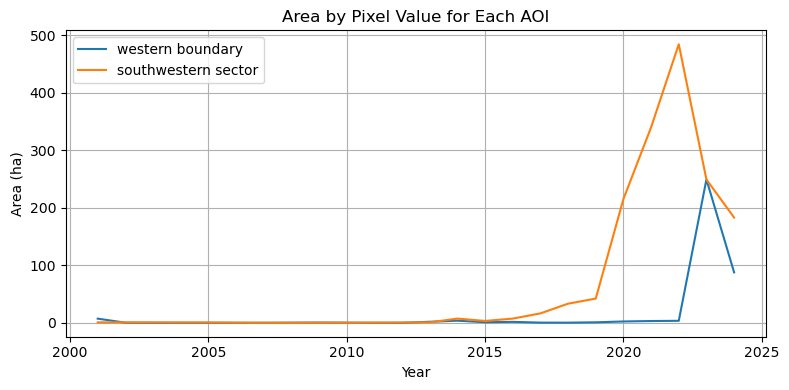

In [17]:
import matplotlib.pyplot as plt

# Filter the data for each AOI
western_data = df[df['AOI'] == 'western boundary']  # or 'PNVi_Area_A' if that's the name in your data
southwestern_data = df[df['AOI'] == 'southwestern sector']  # or 'PNKB_Highland' if that's the name in your data

# Create a figure
plt.figure(figsize=(8, 4))

# Plot the data for PNVi_Area_A
plt.plot(western_data['Year'], western_data['Area (ha)'], label='western boundary') #, marker='o') km

# Plot the data for PNKB_Highland
plt.plot(southwestern_data['Year'], southwestern_data['Area (ha)'], label='southwestern sector') #, marker='o')

# Add labels, title, and legend
plt.xlabel('Year')
plt.ylabel('Area (ha)')
plt.title('Area by Pixel Value for Each AOI')
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
output_path = r"C:\Users\Carol\Dropbox\GIS\Projects\RFO_mining\2_intermediate_data\table"
western_data.to_csv(os.path.join(output_path, 'hansen_annual_deforestation_rfo_w_2024.csv'), index=False)
southwestern_data.to_csv(os.path.join(output_path, 'hansen_annual_deforestation_rfo_sw_2024.csv'), index=False)

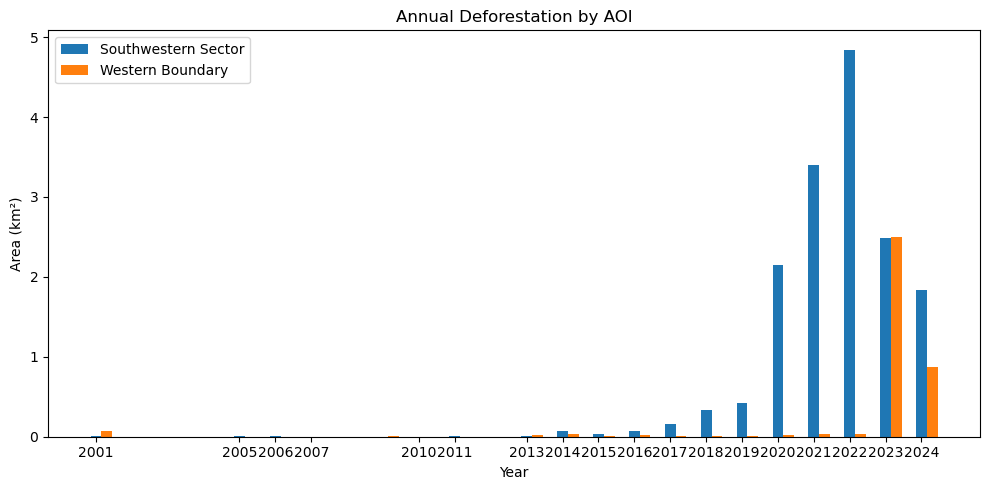

In [21]:
import matplotlib.pyplot as plt

# Filter the data for each AOI
# pnvi_data = df[df['AOI'] == 'PNVi_Area_A']
# pnkb_data = df[df['AOI'] == 'PNKB_Highland']

# Create a figure with subplots
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the annual deforestation for both AOIs
bar_width = 0.3
index = np.arange(len(southwestern_data))

# Plot the data for PNVi_Area_A & PNKB_Highland
bar1 = ax.bar(southwestern_data["Year"], southwestern_data['Area (km²)'], bar_width, label='Southwestern Sector')
bar2 = ax.bar(western_data["Year"] + bar_width, western_data['Area (km²)'], bar_width, label='Western Boundary')

# Add labels, title, and legend
ax.set_xlabel('Year')
ax.set_ylabel('Area (km²)')
ax.set_title('Annual Deforestation by AOI')
# ax.set_xticks(index) # + bar_width / 2)
ax.set_xticks(southwestern_data["Year"]) # + bar_width / 2)
# ax.set_xticklabels(pnkb_data['Pixel Value'])
ax.legend()

# Add labels, title, and legend
plt.legend()

# Show the plot
# plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
southwestern_data.head()

,AOI,Year,Pixel Count,Area (km²),Area (ha)
0,southwestern sector,2001,11,0.008448,0.844822
1,southwestern sector,2005,9,0.006912,0.691218
2,southwestern sector,2006,4,0.003072,0.307208
3,southwestern sector,2007,2,0.001536,0.153604
4,southwestern sector,2010,3,0.002304,0.230406


   Year  Area (km²)
0  2019    3.327496
1  2020    6.288513
2  2021    9.924096
3  2022    1.315325
4  2023   11.711924
5  2024   16.204926
   Year  Area (km²)
0  2019    5.084591
1  2020    8.240757
2  2021    4.953981
3  2022    4.585967
4  2023   12.222842
5  2024    2.613747


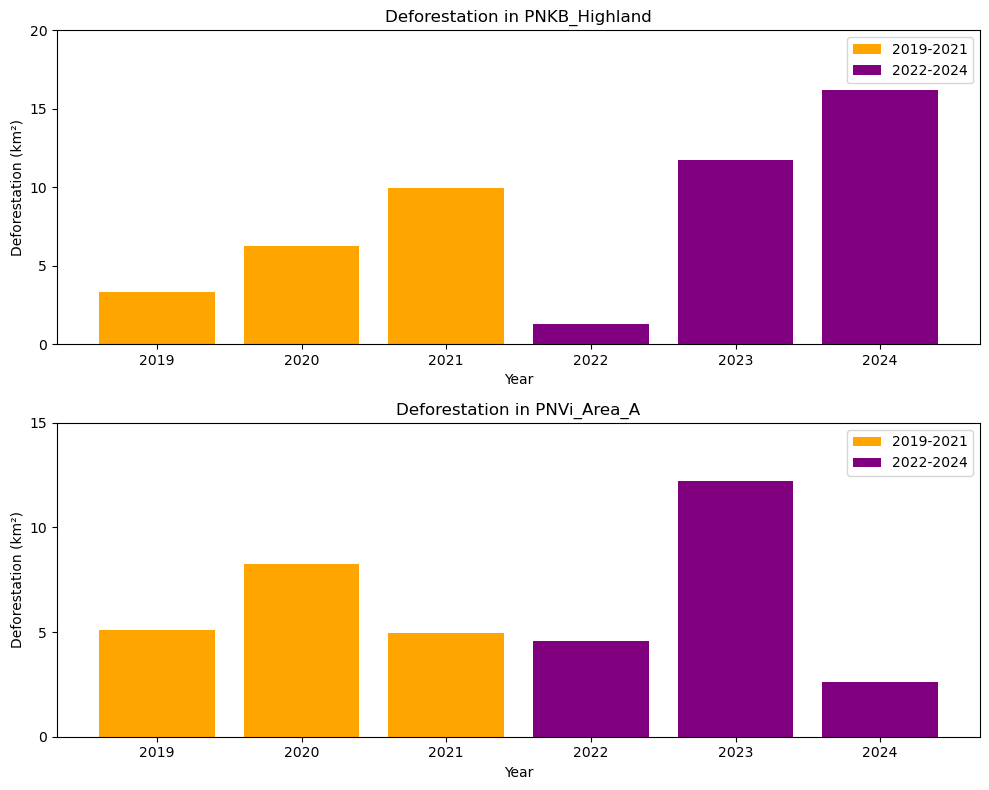

In [43]:
# pnkb_data['Year'] = pnkb_data['Month'].dt.year
# pnvi_data['Year'] = pnvi_data['Month'].dt.year

# annual_deforestation_pnkb = pnkb_data.groupby('Year')['Area (km²)'].sum().reset_index()
# annual_deforestation_pnvi = pnvi_data.groupby('Year')['Area (km²)'].sum().reset_index()

# # Define the periods and colors
# periods = [(2019, 2021), (2022, 2024)]
# colors = ['orange', 'purple']

# # Create a figure with subplots
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot for the first AOI
# ax1 = axes[0]
# for period, color in zip(periods, colors):
#     mask = (annual_deforestation_pnkb['Year'] >= period[0]) & (annual_deforestation_pnkb['Year'] <= period[1])
#     ax1.bar(annual_deforestation_pnkb[mask]['Year'], annual_deforestation_pnkb[mask]['Area (km²)'], color=color, label=f'{period[0]}-{period[1]}')
# ax1.set_xlabel('Year')
# ax1.set_ylabel('Deforestation (km²)')
# ax1.set_title(f'Deforestation in {aoi_names[0]}')
# ax1.legend()

# # Plot for the second AOI
# ax2 = axes[1]
# for period, color in zip(periods, colors):
#     mask = (annual_deforestation_pnvi['Year'] >= period[0]) & (annual_deforestation_pnvi['Year'] <= period[1])
#     ax2.bar(annual_deforestation_pnvi[mask]['Year'], annual_deforestation_pnvi[mask]['Deforestation_SQKM'], color=color, label=f'{period[0]}-{period[1]}')
# ax2.set_xlabel('Year')
# ax2.set_ylabel('Deforestation (km²)')
# ax2.set_title(f'Deforestation in {aoi_names[1]}')
# ax2.legend()

# # Adjust layout
# plt.tight_layout()
# plt.show()

# Define the AOIs
aoi_names = ["PNVi_Area_A", "PNKB_Highland"]

# Filter the data for each AOI
pnvi_data = df[df["AOI"] == aoi_names[0]]
pnkb_data = df[df["AOI"] == aoi_names[1]]


# Group by year and sum area (ensuring missing years are included)
years = np.arange(2019, 2025)  # Ensure 2024 is included
annual_deforestation_pnkb = (
    pnkb_data.set_index("Year")["Area (km²)"]
    .reindex(years, fill_value=0).
    reset_index()
)

annual_deforestation_pnvi = (
    pnvi_data.set_index("Year")["Area (km²)"]
    .reindex(years, fill_value=0)
    .reset_index()
)

print(annual_deforestation_pnkb)
print(annual_deforestation_pnvi)

# # Define the periods and colors
periods = [(2019, 2021), (2022, 2024)]
colors = ["orange", "purple"]

# Create a figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))#, sharey=True)

# Function to plot deforestation data
def plot_deforestation(ax, data, aoi_name):
    for period, color in zip(periods, colors):
        mask = (data["Year"] >= period[0]) & (data["Year"] <= period[1])
        ax.bar(data[mask]["Year"], data[mask]["Area (km²)"], color=color, label=f"{period[0]}-{period[1]}")
    
    ax.set_xticks(years)  # Ensure 2024 remains on X-axis
    ax.set_yticks(np.arange(0, data["Area (km²)"].max() + 5, 5))  # Ensure 2024 remains on X-axis
    ax.set_xlabel("Year")
    ax.set_ylabel("Deforestation (km²)")
    ax.set_title(f"Deforestation in {aoi_name}")
    ax.legend()

# Plot for both AOIs
plot_deforestation(axes[0], annual_deforestation_pnkb, aoi_names[1])
plot_deforestation(axes[1], annual_deforestation_pnvi, aoi_names[0])

# Adjust layout
plt.tight_layout()
plt.show()

In [44]:
index

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

#### Calculate summary data for each AOI

In [45]:
# Initialize a list to hold the summary data
summary_data = []

# Loop over each AOI feature
for idx, aoi in vector_features.iterrows():
    aoi_name = aoi['aoi_name']
    aoi_geom = [aoi['geometry']]
    
    # Mask the raster data with the current AOI
    with rasterio.open(global_forest_cover) as src:
        out_image, out_transform = mask(src, aoi_geom, crop=True)
        data = out_image[0]

        # Create a mask for the deforested pixels (assuming deforestation years are between 1 and 23)
        deforestation_mask = (data >= 1) & (data <= 23)
        
        # Calculate the deforestation area ((27.71818m x 27.71818m pixels)
        # deforestation_area_sqm = np.sum((data >= 1) & (data <= 23)) * 768.2975
        deforestation_area_sqm = np.sum(deforestation_mask) * src.res[0] * src.res[1]  # Pixel area in square meters

        
        # Convert to hectares and square kilometers
        deforestation_area_ha = deforestation_area_sqm / 10_000  # 1 hectare = 10,000 square meters
        deforestation_area_sqkm = deforestation_area_sqm / 1_000_000  # 1 square kilometer = 1,000,000 square meters
        
        # Append the results to the summary data list
        summary_data.append({
            'AOI Name': aoi_name,
            'Deforestation Area (sqm)': deforestation_area_sqm.round(2),
            'Deforestation Area (ha)': deforestation_area_ha.round(2),
            'Deforestation Area (sqkm)': deforestation_area_sqkm.round(2)
        })

# Convert the summary data to a DataFrame
summary_df = pd.DataFrame(summary_data)

# Display the summary DataFrame
print(summary_df)

        AOI Name  Deforestation Area (sqm)  Deforestation Area (ha)  \
0    PNVi_Area_A               48858329.68                  4885.83   
1  PNKB_Highland               39619554.75                  3961.96   

   Deforestation Area (sqkm)  
0                      48.86  
1                      39.62  


In [46]:
# Define the periods
periods = {
    '2001-2018': (2001, 2018),
    '2019-2021': (2019, 2021),
    '2022-2024': (2022, 2024)
}

# Initialize a dictionary to hold the deforestation data for each period
deforestation_by_period = {period: [] for period in periods}

# Open the raster file
with rasterio.open(global_forest_cover) as src:
    # Loop over each AOI feature
    for idx, aoi in vector_features.iterrows():
        aoi_name = aoi['aoi_name']
        geom = [aoi['geometry']]
        
        # Mask the raster data with the current AOI
        out_image, out_transform = mask(src, geom, crop=True)
        data = out_image[0]
        
        # Initialize a dictionary to hold the deforestation area for each period
        deforestation_area_by_period = {period: 0 for period in periods}
        
        # Loop over each pixel in the masked data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the deforestation year from the pixel value
                year = data[y, x]
                
                # If the year is 0, skip to the next pixel (no deforestation)
                if year == 0:
                    continue
                
                # Convert the pixel value to the actual year
                deforestation_year = 2000 + year
                
                # Determine the period for the deforestation year
                for period, (start_year, end_year) in periods.items():
                    if start_year <= deforestation_year <= end_year:
                        # Calculate the deforestation area (27.71818m x 27.71818m pixels)
                        # deforestation_area_by_period[period] += 768.2975  # Pixel area in square meters
                        deforestation_area_by_period[period] += src.res[0] * src.res[1]
                        break
        
        # Append the deforestation data for the current AOI to the dictionary
        for period, area in deforestation_area_by_period.items():
            deforestation_by_period[period].append({
                'AOI Name': aoi_name,
                'Deforestation Area (sqm)': area,
                'Deforestation Area (ha)': area / 10_000,  # 1 hectare = 10,000 square meters
                'Deforestation Area (sqkm)': area / 1_000_000  # 1 square kilometer = 1,000,000 square meters
            })

# Convert the deforestation data to DataFrames for each period
deforestation_dfs = {period: pd.DataFrame(data) for period, data in deforestation_by_period.items()}

# Display the DataFrames
for period, df in deforestation_dfs.items():
    print(f"Deforestation data for {period}:")
    print(df.round(2))
    print()

Deforestation data for 2001-2018:
        AOI Name  Deforestation Area (sqm)  Deforestation Area (ha)  \
0    PNVi_Area_A               13770192.36                  1377.02   
1  PNKB_Highland                7052200.84                   705.22   

   Deforestation Area (sqkm)  
0                      13.77  
1                       7.05  

Deforestation data for 2019-2021:
        AOI Name  Deforestation Area (sqm)  Deforestation Area (ha)  \
0    PNVi_Area_A               18279329.17                  1827.93   
1  PNKB_Highland               19540105.03                  1954.01   

   Deforestation Area (sqkm)  
0                      18.28  
1                      19.54  

Deforestation data for 2022-2024:
        AOI Name  Deforestation Area (sqm)  Deforestation Area (ha)  \
0    PNVi_Area_A               19422555.54                  1942.26   
1  PNKB_Highland               29232175.36                  2923.22   

   Deforestation Area (sqkm)  
0                      19.42  
1     

In [47]:
# Initialize dictionaries to hold the annual deforestation data for each AOI
annual_deforestation_pnkb = {}
annual_deforestation_pnvi = {}

# Open the raster file
with rasterio.open(global_forest_cover) as src:
    # Loop over each vector feature in df_aoi
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name

        print(f"Processing AOI: {aoi_name}")

        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        data = out_image[0]

        # Initialize a dictionary to hold the annual deforestation area for the current AOI
        annual_deforestation = {}

        # Loop over each pixel in the masked data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the deforestation year from the pixel value
                year = data[y, x]
                
                # If the year is 0, skip to the next pixel (no deforestation)
                if year == 0:
                    continue
                
                # Convert the pixel value to the actual year
                deforestation_year = 2000 + year
                
                # Calculate the deforestation area using rasterio (pixel area in square meters)
                deforestation_area_sqm = src.res[0] * src.res[1]
                
                # Add the deforestation area to the annual deforestation dictionary
                if deforestation_year in annual_deforestation:
                    annual_deforestation[deforestation_year] += deforestation_area_sqm
                else:
                    annual_deforestation[deforestation_year] = deforestation_area_sqm

        # Convert the annual deforestation dictionary to a DataFrame
        annual_deforestation_df = pd.DataFrame(list(annual_deforestation.items()), columns=['Year', 'Deforestation_HA'])
        annual_deforestation_df['Deforestation_HA'] = annual_deforestation_df['Deforestation_HA'] / 10_000  # Convert to hectares

        # Add the DataFrame to the appropriate dictionary
        if aoi_name == 'PNKB_Highland':  # Replace with the actual AOI name for PNKB_Highland
            annual_deforestation_pnkb = annual_deforestation_df
        elif aoi_name == 'PNVi_Area_A':  # Replace with the actual AOI name for PNVi_Area_A
            annual_deforestation_pnvi = annual_deforestation_df

# Print the DataFrames
print("Annual Deforestation in PNKB_Highland:")
print(annual_deforestation_pnkb.sort_values(by='Year'))

print("\nAnnual Deforestation in PNVi_Area_A:")
print(annual_deforestation_pnvi.sort_values(by='Year'))

Processing AOI: PNVi_Area_A
Processing AOI: PNKB_Highland
Annual Deforestation in PNKB_Highland:
    Year  Deforestation_HA
12  2001          7.529313
20  2002          4.917103
17  2003          4.686613
15  2004          8.451270
6   2005         20.897686
0   2006         13.522032
14  2007          2.996359
5   2008          5.915889
1   2009         43.562456
7   2010         30.655062
8   2011          6.991505
18  2012          8.604930
2   2013        101.799391
3   2014        135.758131
10  2015        181.779139
9   2016         16.287903
4   2017         44.100265
23  2018         66.765035
22  2019        332.749557
13  2020        628.851333
19  2021        992.409612
21  2022        131.532496
11  2023       1171.192392
16  2024       1620.492648

Annual Deforestation in PNVi_Area_A:
    Year  Deforestation_HA
11  2001         31.039211
10  2002         38.875843
14  2003         19.207432
9   2004         13.214713
6   2005         62.232081
19  2006          4.609784
1

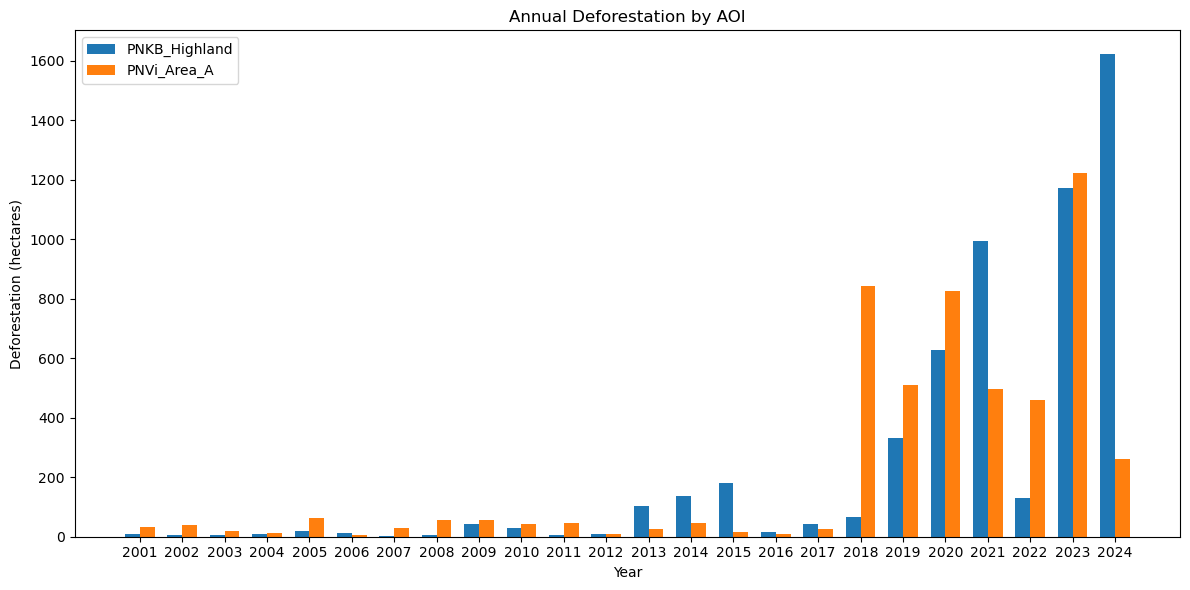

In [48]:
import matplotlib.pyplot as plt

# Ensure both DataFrames have the same range of years
all_years = pd.DataFrame({'Year': range(annual_deforestation_pnkb['Year'].min(), annual_deforestation_pnvi['Year'].max() + 1)})
annual_deforestation_pnkb = all_years.merge(annual_deforestation_pnkb, on='Year', how='left').fillna(0)
annual_deforestation_pnvi = all_years.merge(annual_deforestation_pnvi, on='Year', how='left').fillna(0)

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6))

# Define the bar width and index
bar_width = 0.35
index = np.arange(len(all_years))

# Plot the annual deforestation for both AOIs
bar1 = ax.bar(index, annual_deforestation_pnkb['Deforestation_HA'], bar_width, label='PNKB_Highland')
bar2 = ax.bar(index + bar_width, annual_deforestation_pnvi['Deforestation_HA'], bar_width, label='PNVi_Area_A')

# Add labels, title, and legend
ax.set_xlabel('Year')
ax.set_ylabel('Deforestation (hectares)')
ax.set_title('Annual Deforestation by AOI')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(all_years['Year'])
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

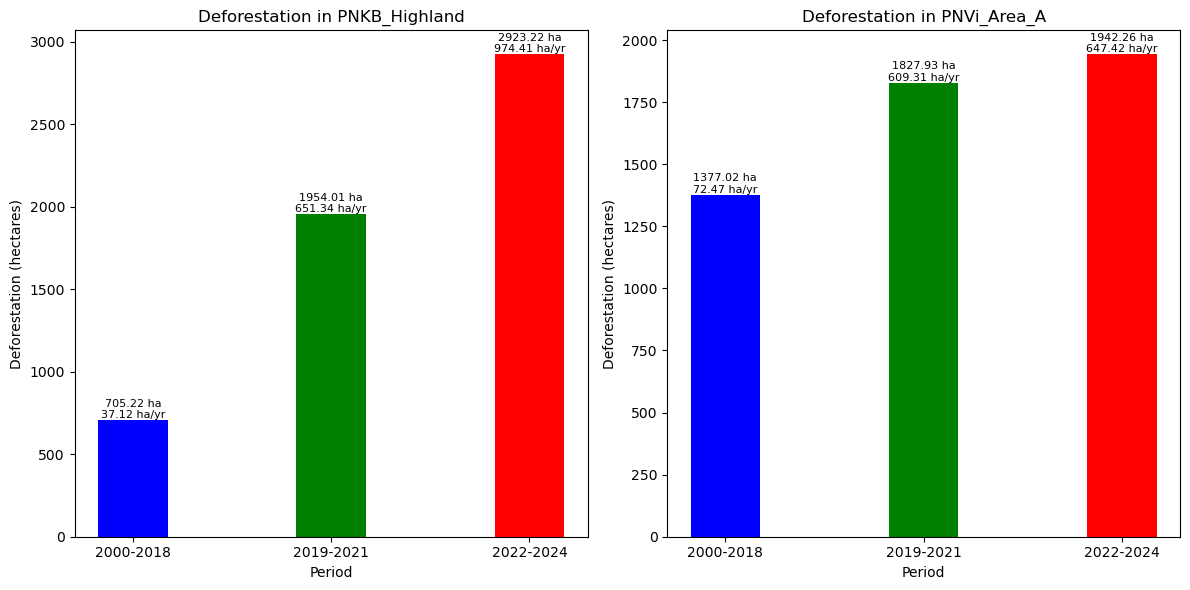

In [49]:
# Define the periods
periods = [(2000, 2018), (2019, 2021), (2022, 2024)]

# Initialize dictionaries to hold the summary data
summary_pnkb = {}
summary_pnvi = {}

# Calculate the summary for PNKB_Highland
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnkb['Year'] >= start_year) & (annual_deforestation_pnkb['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnkb[mask]['Deforestation_HA'].sum()
    summary_pnkb[f'{start_year}-{end_year}'] = total_deforestation

# Calculate the summary for PNVi_Area_A
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnvi['Year'] >= start_year) & (annual_deforestation_pnvi['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnvi[mask]['Deforestation_HA'].sum()
    summary_pnvi[f'{start_year}-{end_year}'] = total_deforestation

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Define the bar width and index
bar_width = 0.35
index = np.arange(len(periods))

# Plot the deforestation for PNKB_Highland
ax1 = axes[0]
bars1 = ax1.bar(index, list(summary_pnkb.values()), bar_width, color=['blue', 'green', 'red'], label='PNKB_Highland')
ax1.set_xlabel('Period')
ax1.set_ylabel('Deforestation (hectares)')
ax1.set_title('Deforestation in PNKB_Highland')
ax1.set_xticks(index)
ax1.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
# ax1.legend()

# Plot the deforestation for PNVi_Area_A
ax2 = axes[1]
bars2 = ax2.bar(index, list(summary_pnvi.values()), bar_width, color=['blue', 'green', 'red'], label='PNVi_Area_A')
ax2.set_xlabel('Period')
ax2.set_ylabel('Deforestation (hectares)')
ax2.set_title('Deforestation in PNVi_Area_A')
ax2.set_xticks(index)
ax2.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
# ax2.legend()

# Add labels for each bar
# for i in range(len(all_years)):
#     # PNKB_Highland
#     total_ha_pnkb = annual_deforestation_pnkb['Deforestation_HA'].iloc[i]
#     annual_rate_pnkb = total_ha_pnkb / 1  # Since it's annual data, the rate is the same as the total
#     ax1.text(i, total_ha_pnkb + 0.1, f'{total_ha_pnkb:.2f} ha\n{annual_rate_pnkb:.2f} ha/yr', ha='center', va='bottom', fontsize=8, color='blue')

#     # PNVi_Area_A
#     total_ha_pnvi = annual_deforestation_pnvi['Deforestation_HA'].iloc[i]
#     annual_rate_pnvi = total_ha_pnvi / 1  # Since it's annual data, the rate is the same as the total
#     ax.text(i + bar_width, total_ha_pnvi + 0.1, f'{total_ha_pnvi:.2f} ha\n{annual_rate_pnvi:.2f} ha/yr', ha='center', va='bottom', fontsize=8, color='green')

# Add labels for each bar
for i, bar in enumerate(bars1):
    height = bar.get_height()
    period = list(summary_pnkb.keys())[i]
    start_year, end_year = map(int, period.split('-'))
    num_years = end_year - start_year + 1
    annual_rate = height / num_years
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f} ha\n{annual_rate:.2f} ha/yr', ha='center', va='bottom', fontsize=8, color='black')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    period = list(summary_pnvi.keys())[i]
    start_year, end_year = map(int, period.split('-'))
    num_years = end_year - start_year + 1
    annual_rate = height / num_years
    ax2.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f} ha\n{annual_rate:.2f} ha/yr', ha='center', va='bottom', fontsize=8, color='black')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
type(deforestation_by_period)

In [ ]:
summary_df

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter the data to include only the years starting from 2019
annual_deforestation_pnkb_filtered = annual_deforestation_pnkb[annual_deforestation_pnkb['Year'] >= 2019]
annual_deforestation_pnvi_filtered = annual_deforestation_pnvi[annual_deforestation_pnvi['Year'] >= 2019]

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Define the bar width and index
bar_width = 0.35
index_pnkb = np.arange(len(annual_deforestation_pnkb_filtered))
index_pnvi = np.arange(len(annual_deforestation_pnvi_filtered))

# Plot the annual deforestation for PNKB_Highland
ax1 = axes[0]
ax1.bar(index_pnkb, annual_deforestation_pnkb_filtered['Deforestation_HA'], bar_width, color='blue', label='PNKB_Highland')
ax1.set_xlabel('Year')
ax1.set_ylabel('Deforestation (hectares)')
ax1.set_title('Annual Deforestation in PNKB_Highland')
ax1.set_xticks(index_pnkb)
ax1.set_xticklabels(annual_deforestation_pnkb_filtered['Year'])
ax1.legend()

# Plot the annual deforestation for PNVi_Area_A
ax2 = axes[1]
ax2.bar(index_pnvi, annual_deforestation_pnvi_filtered['Deforestation_HA'], bar_width, color='green', label='PNVi_Area_A')
ax2.set_xlabel('Year')
ax2.set_ylabel('Deforestation (hectares)')
ax2.set_title('Annual Deforestation in PNVi_Area_A')
ax2.set_xticks(index_pnvi)
ax2.set_xticklabels(annual_deforestation_pnvi_filtered['Year'])
ax2.legend()

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the periods
periods = [(2000, 2018), (2019, 2021), (2022, 2024)]

# Initialize dictionaries to hold the summary data
summary_pnkb = {}
summary_pnvi = {}

# Calculate the summary for PNKB_Highland
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnkb['Year'] >= start_year) & (annual_deforestation_pnkb['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnkb[mask]['Deforestation_HA'].sum()
    summary_pnkb[f'{start_year}-{end_year}'] = total_deforestation

# Calculate the summary for PNVi_Area_A
for period in periods:
    start_year, end_year = period
    mask = (annual_deforestation_pnvi['Year'] >= start_year) & (annual_deforestation_pnvi['Year'] <= end_year)
    total_deforestation = annual_deforestation_pnvi[mask]['Deforestation_HA'].sum()
    summary_pnvi[f'{start_year}-{end_year}'] = total_deforestation

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Define the bar width and index
bar_width = 0.35
index = np.arange(len(periods))

# Plot the deforestation for PNKB_Highland
ax1 = axes[0]
ax1.bar(index, list(summary_pnkb.values()), bar_width, color=['blue', 'green', 'red'], label='PNKB_Highland')
ax1.set_xlabel('Period')
ax1.set_ylabel('Deforestation (hectares)')
ax1.set_title('Deforestation in PNKB_Highland')
ax1.set_xticks(index)
ax1.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
ax1.legend()

# Plot the deforestation for PNVi_Area_A
ax2 = axes[1]
ax2.bar(index, list(summary_pnvi.values()), bar_width, color=['blue', 'green', 'red'], label='PNVi_Area_A')
ax2.set_xlabel('Period')
ax2.set_ylabel('Deforestation (hectares)')
ax2.set_title('Deforestation in PNVi_Area_A')
ax2.set_xticks(index)
ax2.set_xticklabels([f'{start_year}-{end_year}' for start_year, end_year in periods])
ax2.legend()

# Adjust layout
plt.tight_layout()
plt.show()

### Grouping results into annual deforestation bins

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate the deforestation alerts into annual buckets
df_aoi_pnkb['Year'] = df_aoi_pnkb['Month'].dt.year
df_aoi_pnvi['Year'] = df_aoi_pnvi['Month'].dt.year

annual_deforestation_pnkb = df_aoi_pnkb.groupby('Year')['Deforestation_HA'].sum().reset_index()
annual_deforestation_pnvi = df_aoi_pnvi.groupby('Year')['Deforestation_HA'].sum().reset_index()

# Define the periods and colors
periods = [(2019, 2021), (2022, 2024)]
colors = ['blue', 'green']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot for the first AOI
ax1 = axes[0]
for period, color in zip(periods, colors):
    mask = (annual_deforestation_pnkb['Year'] >= period[0]) & (annual_deforestation_pnkb['Year'] <= period[1])
    ax1.bar(annual_deforestation_pnkb[mask]['Year'], annual_deforestation_pnkb[mask]['Deforestation_HA'], color=color, label=f'{period[0]}-{period[1]}')
ax1.set_xlabel('Year')
ax1.set_ylabel('Deforestation (hectares)')
ax1.set_title(f'Deforestation in {aoi_names[0]}')
ax1.legend()

# Plot for the second AOI
ax2 = axes[1]
for period, color in zip(periods, colors):
    mask = (annual_deforestation_pnvi['Year'] >= period[0]) & (annual_deforestation_pnvi['Year'] <= period[1])
    ax2.bar(annual_deforestation_pnvi[mask]['Year'], annual_deforestation_pnvi[mask]['Deforestation_HA'], color=color, label=f'{period[0]}-{period[1]}')
ax2.set_xlabel('Year')
ax2.set_ylabel('Deforestation (hectares)')
ax2.set_title(f'Deforestation in {aoi_names[1]}')
ax2.legend()

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
selected_aoi_names

In [ ]:
vector_features

In [ ]:

global_forest_cover_by_aoi = {}

# Define the periods and colors
periods = [(2000, 2018), (2019, 2021), (2022, 2023)]
colors = ['blue', 'green', 'red']

# Open the raster file
with rasterio.open(global_forest_cover) as src:
    # geom = [df_aoi['geometry'].iloc[0]]

    # print(f'Processing AOI: {aoi_name}')

    # Loop over each AOI feature
    for idx, aoi in vector_features.iterrows():
        geom = [aoi['geometry']]
        aoi_name = aoi['aoi_name']
        # aoi_area_ha = aoi['AOI_Area_sqkm']

        print(f"Processing AOI: {aoi_name}")

        # Mask the raster data with the current AOI
        out_image, out_transform = mask(src, geom, crop=True)
        data = out_image[0]

        # Create a list to hold the deforestation data
        deforestation_years = []

        # Loop over each pixel in the masked data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the deforestation year from the pixel value
                year = data[y, x]
                
                # If the year is 0, skip to the next pixel (no deforestation)
                if year == 0:
                    continue
                
                # Convert the pixel value to the actual year
                deforestation_year = 2000 + year - 1
                
                # Add the deforestation year to the list
                deforestation_years.append(deforestation_year)

        # Convert the deforestation years to a DataFrame
        df_deforestation = pd.DataFrame(deforestation_years, columns=['Year'])

        # Aggregate the deforestation data into the specified periods
        df_deforestation['Period'] = pd.cut(df_deforestation['Year'], bins=[1999, 2018, 2021, 2023], labels=['2000-2018', '2019-2021', '2022-2023'])
        annual_deforestation = df_deforestation['Period'].value_counts().sort_index()

        # Create a bar plot for the current AOI
        fig, ax = plt.subplots(figsize=(8, 6))
        for period, color in zip(periods, colors):
            period_label = f'{period[0]}-{period[1]}'
            if period_label in annual_deforestation.index:
                ax.bar(period_label, annual_deforestation[period_label], color=color, label=period_label)
        ax.set_xlabel('Period')
        ax.set_ylabel('Deforestation (number of pixels)')
        ax.set_title(f'Deforestation in {aoi_name}')
        ax.legend()

        # Show the plot
        plt.show()

# Loop over each AOI feature and process it
for idx, aoi in vector_features.iterrows():
    aoi_geom = aoi['geometry']
    aoi_name = aoi['aoi_name']  # Replace with the actual field name for AOI name
    # process_aoi(aoi_geom, aoi_name)

In [ ]:
# Create a list to hold the output data
output = []

In [ ]:
# Loop over each pixel in the data array
for y in range(height):
    for x in range(width):
        # Get the alert value from the data array
        alert = data[y,x]
        
        # If the alert value is 0, skip to the next pixel
        if alert == 0:
            continue
        
        # Determine the confidence level and number of days since Dec 31, 2014
        conf = int(str(alert)[0])
        days = int(str(alert)[1:])
        date = np.datetime64('2014-12-31') + np.timedelta64(days, 'D')
        
        # Convert the pixel coordinates to longitude and latitude
        lon, lat = rasterio.transform.xy(transform, y, x)
        
        # Add the data to the output list
        output.append([alert, lon, lat, date, conf])

In [ ]:
# Write the output list to a CSV file
with open('GFW_alerts_parsed.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Alert','Longitude', 'Latitude', 'Date', 'Confidence'])
    writer.writerows(output)

In [ ]:
with rasterio.open(raster_path) as src:
    # Create a window from the bbox
    window = from_bounds(*bbox, transform=src.transform)
    data = src.read(1, window=window)

    # Initialize a dictionary to hold the deforestation area for each AOI
    deforestation_by_aoi = {}

    # Loop over each vector feature
    for idx, feature in vector_features.iterrows():
        geom = [feature['geometry']]
        aoi_name = feature['aoi_name']  # Replace with the actual field name for AOI name
        
        # Mask the raster data with the current vector feature
        out_image, out_transform = mask(src, geom, crop=True)
        
        # Get the data array from the masked raster
        data = out_image[0]
        
        # Initialize a variable to hold the deforestation area for the current AOI
        deforestation_area_sqm = 0

        # Loop over each pixel in the data array
        for y in range(data.shape[0]):
            for x in range(data.shape[1]):
                # Get the alert value from the data array
                alert = data[y, x]
                
                # If the alert value is 0, skip to the next pixel
                if alert == 0:
                    continue

                # Determine the confidence level
                conf = int(str(alert)[0])
                
                # Only process alert levels 3 or 4
                if conf not in [3, 4]:
                # if conf not in [4]:
                    continue
                
                # Calculate the deforestation area (10m x 10m pixels)
                deforestation_area_sqm += 10 * 10  # Pixel area in square meters
        
        # Calculate the deforestation area (10m x 10m pixels)
        # deforestation_area_sqm = np.sum(data > 0) * 10 * 10  # Sum of non-zero pixels times pixel area

         # Convert to hectares and square kilometers
        deforestation_area_ha = deforestation_area_sqm / 10_000  # 1 hectare = 10,000 square meters
        deforestation_area_sqkm = deforestation_area_sqm / 1_000_000  # 1 square kilometer = 1,000,000 square meters
        
        # Add the deforestation area to the dictionary
        if aoi_name in deforestation_by_aoi:
            deforestation_by_aoi[aoi_name]['sqm'] += deforestation_area
            deforestation_by_aoi[aoi_name]['ha'] += deforestation_area_ha
            deforestation_by_aoi[aoi_name]['sqkm'] += deforestation_area_sqkm
        else:
            deforestation_by_aoi[aoi_name] = {
                'sqm': deforestation_area_sqm,
                'ha': deforestation_area_ha,
                'sqkm': deforestation_area_sqkm
            }

# Print the deforestation area for each AOI
for aoi_name, areas in deforestation_by_aoi.items():
    print(f"Total deforestation area in {aoi_name}:")
    print(f"  {areas['sqm']} square meters")
    print(f"  {areas['ha']} hectares")
    print(f"  {areas['sqkm']} square kilometers")